<h1 align="center">
    THIS NOTEBOOK IS A PERSONAL REPRODUCTION AND REWORK OF THE Qiskit Machine Learning TUTORIAL
    <a href="https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html">
        Quantum Neaural Networks
    </a>
</h1>

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as ExactEstimator, StatevectorSampler as ExactSampler

from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN

import numpy as np

In [2]:
# Set the algorithmic seed to ensure that the results don’t change between runs
algorithm_globals.random_seed = 42

# Instantiate QNNs

### Estimator QNN

Initalize a sample EstimatorQNN with one parameter representing the input and one representing the trainable weight.

The EstimatorQNN constructor takes in the following keyword arguments:
* circuit: the Quantum Circuit to run

* observables: the observable(s) whose expectation value is to be estimated. Default is Z on all qubits.

* estimator: optional primitive instance

* pass_manager: optional pass_manager instance for primitives that require transpilation

* input_params: list of quantum circuit parameters that should be treated as “network inputs”

* weight_params: list of quantum circuit parameters that should be treated as “network weights”

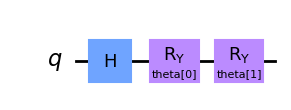

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Observable: SparsePauliOp(['Y'],
              coeffs=[1.+0.j])



In [31]:
# Create the circuit
parameters = ParameterVector("theta", 2)

qc_est = QuantumCircuit(1)
qc_est.h(0)
qc_est.ry(parameters[0], 0)
qc_est.ry(parameters[1], 0)
display(qc_est.draw("mpl", style = "clifford"))

# Define the observable whose expectation value is to be estimated
observable1 = SparsePauliOp("Y" * qc_est.num_qubits, 1)
print(f"Observable: {observable1}\n")

# Define a local estimator simulator using StatevectorEstimator
exact_estimator = ExactEstimator()
estimatorQNN = EstimatorQNN(
    circuit = qc_est,
    observables = observable1,
    estimator = exact_estimator,
    pass_manager = None,
    input_params = [parameters[0]],
    weight_params = [parameters[1]]
)
estimatorQNN

### Sampler QNN

Initalize a sample SamplerQNN with two parameters representing the input and four representing the trainable weights.

The SamplerQNN constructor takes in the following keyword arguments:
* circuit: the Quantum Circuit to run

* sampler: optional primitive instance

* pass_manager: optional pass_manager instance for primitives that require transpilation.

* input_params: list of quantum circuit parameters that should be treated as “network inputs”

* weight_params: list of quantum circuit parameters that should be treated as “network weights”

* interpret: function to post-process the samples. It takes a measured integer (from a bitstring) and maps it to a new value, i.e. non-negative integer. This function determines the output_shape

Input parameters: ['input_params[0]', 'input_params[1]']

Weight parameters: ['weight_params[0]', 'weight_params[1]', 'weight_params[2]', 'weight_params[3]']



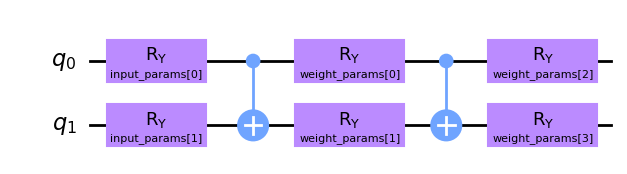

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [32]:
# Create the circuit
input_par = ParameterVector("input_params", 2)
weight_par = ParameterVector("weight_params", 4)
print(f"Input parameters: {[str(param) for param in input_par.params]}\n")
print(f"Weight parameters: {[str(param) for param in weight_par.params]}\n")

qc_sampl = QuantumCircuit(2)
qc_sampl.ry(input_par[0], 0)
qc_sampl.ry(input_par[1], 1)
qc_sampl.cx(0, 1)
qc_sampl.ry(weight_par[0], 0)
qc_sampl.ry(weight_par[1], 1)
qc_sampl.cx(0, 1)
qc_sampl.ry(weight_par[2], 0)
qc_sampl.ry(weight_par[3], 1)
display(qc_sampl.draw("mpl", style = "clifford"))

# Define a local sampler simulator using StatevectorEstimator
exact_sampler = ExactSampler()
samplerQNN = SamplerQNN(
    circuit = qc_sampl,
    sampler = exact_sampler,
    input_params = input_par,
    weight_params = weight_par
)
samplerQNN

# Run a Forward Pass

In EstimatorQNN, the forward pass returns an array of shape (batch_size, num_observables), where batch_size is the number of input samples and num_observables is the length of the observables list.

For the SamplerQNN (without custom interpret function), the expected output shape for the forward pass is (batch_size, 2**num_qubits). With a custom interpret function, the output shape will be (batch_size, output_shape)

### Set-up input and weights parameters

In a real setting, the inputs would be defined by the dataset, and the weights would be defined by the training algorithm or as part of a pre-trained model. However, for the sake of this tutorial, we will specify random sets of input and weights of the right dimension

In [5]:
# EstimatorQNN
estimator_qnn_input = algorithm_globals.random.random(estimatorQNN.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(estimatorQNN.num_weights)
print(f"Number of input features for EstimatorQNN: {estimatorQNN.num_inputs} \nInput: {estimator_qnn_input}\n")
print(f"Number of trainable weights for EstimatorQNN: {estimatorQNN.num_weights} \nWeights: {estimator_qnn_weights}\n")

Number of input features for EstimatorQNN: 1 
Input: [0.77395605]

Number of trainable weights for EstimatorQNN: 1 
Weights: [0.43887844]



In [6]:
# SamplerQNN
sampler_qnn_input = algorithm_globals.random.random(samplerQNN.num_inputs)
sampler_qnn_weights = algorithm_globals.random.random(samplerQNN.num_weights)
print(f"Number of input features for SamplerQNN: {samplerQNN.num_inputs} \nInput: {sampler_qnn_input}\n")
print(f"Number of trainable weights for SamplerQNN: {samplerQNN.num_weights} \nWeights: {sampler_qnn_weights}")

Number of input features for SamplerQNN: 2 
Input: [0.85859792 0.69736803]

Number of trainable weights for SamplerQNN: 4 
Weights: [0.09417735 0.97562235 0.7611397  0.78606431]


### Non-batched Forward Pass

In [7]:
# EstimatorQNN
estimator_qnn_forward = estimatorQNN.forward(estimator_qnn_input, estimator_qnn_weights)
print(f"Forward pass result for EstimatorQNN: {estimator_qnn_forward}. \nShape: {estimator_qnn_forward.shape}")

Forward pass result for EstimatorQNN: [[-0.00766754]]. 
Shape: (1, 1)


In [8]:
# SamplerQNN
sampler_qnn_forward = samplerQNN.forward(sampler_qnn_input, sampler_qnn_weights)
print(f"Forward pass result for SamplerQNN: {sampler_qnn_forward}.  \nShape: {sampler_qnn_forward.shape}")

Forward pass result for SamplerQNN: [[0.01855469 0.25292969 0.52148438 0.20703125]].  
Shape: (1, 4)


### Batched Forward Pass

In [9]:
# EstimatorQNN
estimator_qnn_forward_batched = estimatorQNN.forward([estimator_qnn_input, estimator_qnn_input], estimator_qnn_weights)
print(f"Forward pass result for EstimatorQNN: {estimator_qnn_forward_batched}.  \nShape: {estimator_qnn_forward_batched.shape}")

Forward pass result for EstimatorQNN: [[-0.00747936]
 [ 0.01886121]].  
Shape: (2, 1)


In [10]:
# SamplerQNN
sampler_qnn_forward_batched = samplerQNN.forward([sampler_qnn_input, sampler_qnn_input], sampler_qnn_weights)
print(f"Forward pass result for SamplerQNN: {sampler_qnn_forward_batched}.  \nShape: {sampler_qnn_forward_batched.shape}")

Forward pass result for SamplerQNN: [[0.02539062 0.24804688 0.5234375  0.203125  ]
 [0.015625   0.27050781 0.52441406 0.18945312]].  
Shape: (2, 4)


# Run a Backward Pass

The backward pass returns a tuple (input_gradients, weight_gradients). By default, the backward pass will only calculate gradients with respect to the weight parameters.

If you want to enable gradients with respect to the input parameters, you should set the following flag during the QNN instantiation:
- qnn = ...QNN(..., input_gradients=True)

Please remember that input gradients are required for the use of TorchConnector for PyTorch integration.

For the EstimatorQNN, the expected output shape for the weight gradients is (batch_size, num_qubits * num_observables, num_weights), while for the input gradients is (batch_size, num_qubits * num_observables, num_inputs)

For the SamplerQNN (without custom interpret function), the expected output shape for the weight gradients is (batch_size, 2^num_qubits, num_weights), while for the input gradients is (batch_size, 2^num_qubits, num_inputs). With a custom interpret function, the output shape will be (batch_size, output_shape, num_weights) for the weight gradient and (batch_size, output_shape, num_inputs) for the input gradient.

### Backward Pass without Input Gradients

In [11]:
# EstimatorQNN
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimatorQNN.backward(estimator_qnn_input, estimator_qnn_weights)
print(f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad}\n")
print(f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}")

Input gradients for EstimatorQNN: None.  
Shape: None

Weight gradients for EstimatorQNN: [[[0.]]].  
Shape: (1, 1, 1)


In [12]:
# SamplerQNN
sampler_qnn_input_grad, sampler_qnn_weight_grad = samplerQNN.backward(sampler_qnn_input, sampler_qnn_weights)
print(f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad}\n")
print(f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}")

Input gradients for SamplerQNN: None.  
Shape: None

Weight gradients for SamplerQNN: [[[ 0.00830078 -0.09863281 -0.07080078 -0.10400391]
  [ 0.19628906 -0.07958984  0.06787109 -0.20996094]
  [-0.49023438  0.30859375 -0.31884766  0.08447266]
  [ 0.28564453 -0.13037109  0.32177734  0.22949219]]].  
Shape: (1, 4, 4)


### Backward Pass with Input Gradients

In [13]:
estimatorQNN.input_gradients = True
samplerQNN.input_gradients = True

In [14]:
# EstimatorQNN
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimatorQNN.backward(estimator_qnn_input, estimator_qnn_weights)
print(f"Input gradients for EstimatorQNN: {estimator_qnn_input_grad}.  \nShape: {estimator_qnn_input_grad.shape}\n")
print(f"Weight gradients for EstimatorQNN: {estimator_qnn_weight_grad}.  \nShape: {estimator_qnn_weight_grad.shape}")

Input gradients for EstimatorQNN: [[[0.]]].  
Shape: (1, 1, 1)

Weight gradients for EstimatorQNN: [[[0.]]].  
Shape: (1, 1, 1)


In [15]:
# SamplerQNN
sampler_qnn_input_grad, sampler_qnn_weight_grad = samplerQNN.backward(sampler_qnn_input, sampler_qnn_weights)
print(f"Input gradients for SamplerQNN: {sampler_qnn_input_grad}.  \nShape: {sampler_qnn_input_grad.shape}\n")
print(f"Weight gradients for SamplerQNN: {sampler_qnn_weight_grad}.  \nShape: {sampler_qnn_weight_grad.shape}")

Input gradients for SamplerQNN: [[[-0.05810547 -0.09472656]
  [ 0.390625   -0.20556641]
  [-0.3515625   0.09277344]
  [ 0.01904297  0.20751953]]].  
Shape: (1, 4, 2)

Weight gradients for SamplerQNN: [[[ 0.00927734 -0.1171875  -0.06982422 -0.10839844]
  [ 0.20996094 -0.09082031  0.06933594 -0.21728516]
  [-0.48583984  0.32958984 -0.33300781  0.09619141]
  [ 0.26660156 -0.12158203  0.33349609  0.22949219]]].  
Shape: (1, 4, 4)


# Advanced Functionality

### EstimatorQNN with Multiple Observables

The EstimatorQNN allows to pass lists of observables for more complex QNN architectures.

In [33]:
# Instantiate an EstimatorQNN
observable2 = SparsePauliOp("Z" * qc_est.num_qubits, 1)

exact_estimator = ExactEstimator()
estimatorQNN2 = EstimatorQNN(
    circuit = qc_est,
    observables = [observable1, observable2],
    input_params = [parameters[0]],
    weight_params = [parameters[1]],
    estimator = exact_estimator,
)

# Forward pass
estimator_qnn_input = algorithm_globals.random.random(estimatorQNN2.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(estimatorQNN2.num_weights)
estimator_qnn_forward2 = estimatorQNN2.forward(estimator_qnn_input, estimator_qnn_weights)

# Backward pass
estimator_qnn_input_grad2, estimator_qnn_weight_grad2 = estimatorQNN2.backward(estimator_qnn_input, estimator_qnn_weights)

print(f"Forward output shape for EstimatorQNN1: {estimator_qnn_forward.shape}")
print(f"Forward output shape for EstimatorQNN2: {estimator_qnn_forward2.shape}")
print(f"Backward output shape for EstimatorQNN1: {estimator_qnn_weight_grad.shape}")
print(f"Backward output shape for EstimatorQNN2: {estimator_qnn_weight_grad2.shape}")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Forward output shape for EstimatorQNN1: (1, 1)
Forward output shape for EstimatorQNN2: (1, 2)
Backward output shape for EstimatorQNN1: (1, 1, 1)
Backward output shape for EstimatorQNN2: (1, 2, 1)


### SamplerQNN with custom interpret

Interpret functions modifies the output shape of the forward and backward passes.
One common interpret method for SamplerQNN is the parity function, which allows it to perform binary classification. In the case of the parity interpret function, output_shape is fixed to 2 $\Rightarrow$ forward and weight gradient shapes are (batch_size, 2) and (batch_size, 2, num_weights)

In [34]:
# Define the interpret function
parity = lambda x: "{:b}".format(x).count("1") % 2
output_shape = 2  # parity = 0, 1

# Instantiate a SamplerQNN
exact_sampler = ExactSampler()
samplerQNN2 = SamplerQNN(
    circuit = qc_sampl,
    input_params = input_par,
    weight_params = weight_par,
    interpret = parity,
    output_shape = output_shape,
    sampler = exact_sampler,
)

# Forward pass
estimator_qnn_input = algorithm_globals.random.random(samplerQNN2.num_inputs)
estimator_qnn_weights = algorithm_globals.random.random(samplerQNN2.num_weights)
sampler_qnn_forward2 = samplerQNN2.forward(sampler_qnn_input, sampler_qnn_weights)

# Backward pass
sampler_qnn_input_grad2, sampler_qnn_weight_grad2 = samplerQNN2.backward(
    sampler_qnn_input, sampler_qnn_weights
)

print(f"Forward output for SamplerQNN1: {sampler_qnn_forward.shape}")
print(f"Forward output for SamplerQNN2: {sampler_qnn_forward2.shape}")
print(f"Backward output for SamplerQNN1: {sampler_qnn_weight_grad.shape}")
print(f"Backward output for SamplerQNN2: {sampler_qnn_weight_grad2.shape}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Forward output for SamplerQNN1: (1, 4)
Forward output for SamplerQNN2: (1, 2)
Backward output for SamplerQNN1: (1, 4, 4)
Backward output for SamplerQNN2: (1, 2, 4)


# Copyright

This code is a part of a Qiskit project
© Copyright IBM 2017, 2025.

This code is licensed under the Apache License, Version 2.0. You may
obtain a copy of this license in the LICENSE.txt file in the root directory
of this source tree or at http://www.apache.org/licenses/LICENSE-2.0.